In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression

In [3]:
X,Y = make_regression(n_samples = 100,n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)


In [4]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2)


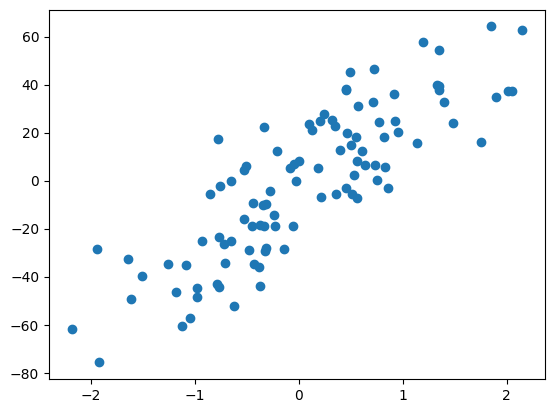

In [5]:
plt.scatter(X,Y)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
LR = LinearRegression()
LR.fit(x_train,y_train)


LinearRegression()

In [9]:
y_pred = LR.predict(x_test)

In [10]:
print(LR.coef_)
print(LR.intercept_)

[27.78003827]
-1.5073298953743233


C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.155e+04, tolerance: 7.908e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using on

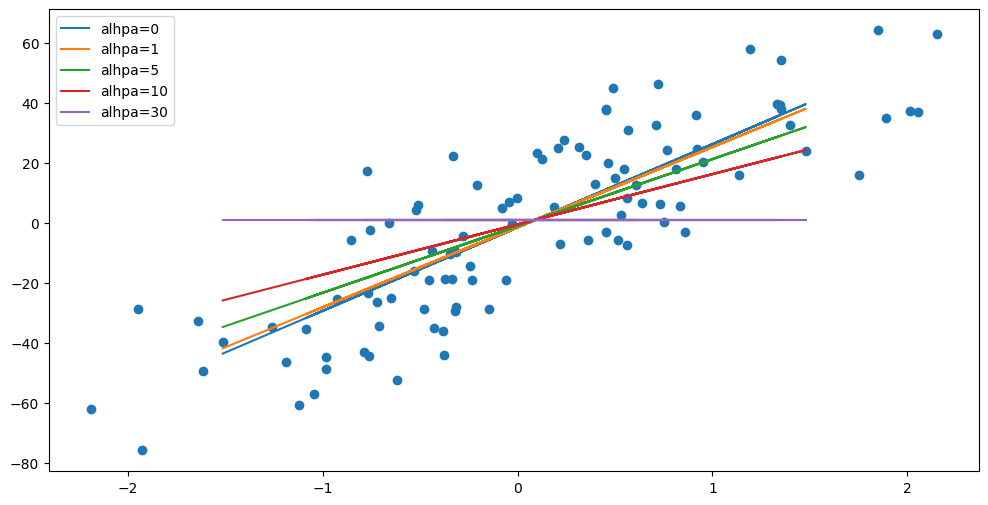

In [16]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,Y)
for i in alphas:
    L=Lasso(alpha = i)
    L.fit(x_train,y_train)
    plt.plot(x_test,L.predict(x_test),label = 'alhpa={}'.format(i))
plt.legend()
plt.show()

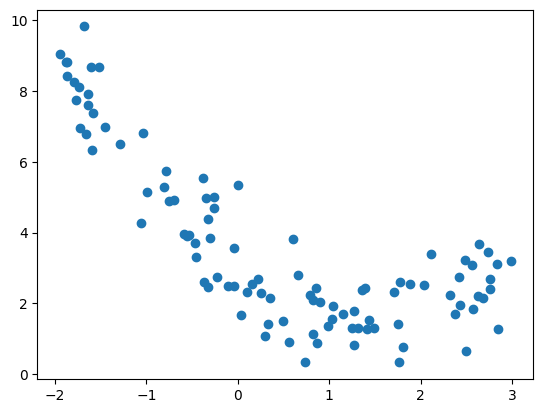

In [17]:
# Lasso on Non_Linear dataset
m = 100
x1 = 5*np.random.rand(m,1) - 2
x2 = 0.7* x1 ** 2 -2 * x1 +3+np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\anmol sarin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.425e+01, tolerance: 5.813e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using on

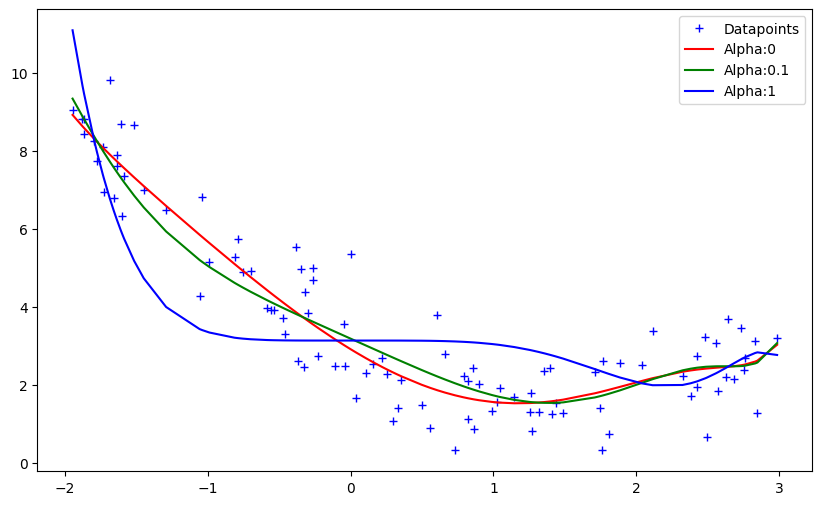

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
def get_preds_lesso(x1,x2, alpha):
    model = Pipeline([
        ('ploy_feats',PolynomialFeatures (degree=16) ),
        ('lasso', Lasso(alpha = alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)
    
alphas = [0,0.1,1]
cs = ['r', 'g','b']

plt.figure(figsize = (10,6))
plt.plot(x1, x2, 'b+', label='Datapoints')
for alpha, c in zip(alphas, cs):
    preds = get_preds_lesso(x1,x2, alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])], c, label='Alpha:{}'.format(alpha))
plt.legend()
plt.show()